# Modèle Random-Forest

## Bibliothèques importés

In [2]:
import mysql.connector
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.tree import plot_tree
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## Connection BDD

In [3]:
conn = mysql.connector.connect(
    host='localhost', 
    database='gamesale',
    user='root', 
    password='', 
    charset='utf8'
)

## Chargement des tables et nettoyage des données

In [4]:
jeux      = pd.read_sql("SELECT id_jeu, nom_jeu, annee, age_requis, nb_succes, nb_avis_pos, nb_avis_neg, temps_jeu_moyen, prix, ventes_Global FROM jeux", conn)
genre      = pd.read_sql("SELECT id_jeu, genre FROM genre", conn)
cat_link   = pd.read_sql("SELECT id_jeu, id_cat FROM a_categorie WHERE id_cat != ''", conn)
cat_names  = pd.read_sql("SELECT id_cat, categorie FROM categorie", conn)
os = pd.read_sql("SELECT id_os, OS FROM os", conn)
os_link  = pd.read_sql("SELECT id_jeu, id_os FROM a_os", conn)
developpeurs = pd.read_sql("SELECT id_jeu, id_developpeur, developpeur FROM developpeur", conn)
editeurs = pd.read_sql("SELECT id_jeu, id_editeur, editeur FROM editeur", conn)
tags = pd.read_sql("SELECT * FROM a_tag", conn)

#on convertit les virgules en points
def to_number(x):
    try: 
        return float(str(x).replace(",", "."))
    except: 
        return None

for col in ["ventes_Global", "annee", "prix", "age_requis", "nb_succes", "nb_avis_pos", "nb_avis_neg", "temps_jeu_moyen"]:
    jeux[col] = jeux[col].apply(to_number)

genre_lists = genre.groupby("id_jeu")["genre"].apply(list).reset_index()
#on utilise mlb au lieu de label encoder car un jeu peut appartenir à plusieurs catégories
#label encoder est que pour les variables à valeur unique
mlb_genre = MultiLabelBinarizer()
genre_matrix = mlb_genre.fit_transform(genre_lists["genre"])
column_names_genre = []
for g in mlb_genre.classes_:
    column_names_genre.append("genre_" + g)
genre_dummies = pd.DataFrame(genre_matrix, columns=column_names_genre, index=genre_lists["id_jeu"]).reset_index()
print(genre_dummies)

cat_link["id_cat"] = pd.to_numeric(cat_link["id_cat"], errors="coerce")
cat_named = cat_link.merge(cat_names, on="id_cat", how="left")
cat_lists = cat_named.groupby("id_jeu")["categorie"].apply(list).reset_index()
mlb_cat = MultiLabelBinarizer()
cat_matrix = mlb_cat.fit_transform(cat_lists["categorie"])
column_names_cat = []
for c in mlb_cat.classes_:
    column_names_cat.append("cat_" + c)
cat_dummies = pd.DataFrame(cat_matrix, columns=column_names_cat, index=cat_lists["id_jeu"]).reset_index()
print(cat_dummies)

os_named = os_link.merge(os, on="id_os", how="left")
os_lists = os_named.groupby("id_jeu")["OS"].apply(list).reset_index()

mlb_os = MultiLabelBinarizer()
os_matrix = mlb_os.fit_transform(os_lists["OS"])
column_names_os = []
for o in mlb_os.classes_:
    column_names_os.append("os_" + o)
os_dummies = pd.DataFrame(os_matrix, columns=column_names_os, index=os_lists["id_jeu"]).reset_index()
print(os_dummies)

le_dev = LabelEncoder()
le_pub = LabelEncoder()
developpeurs["dev_encoded"] = le_dev.fit_transform(developpeurs["developpeur"])
editeurs["pub_encoded"] = le_pub.fit_transform(editeurs["editeur"])

     id_jeu  genre_Action  genre_Adventure  genre_Fighting  genre_Misc  \
0         1             1                0               0           0   
1         2             1                0               0           0   
2         3             1                0               0           0   
3         4             0                0               0           0   
4         5             0                0               0           0   
..      ...           ...              ...             ...         ...   
775     776             0                0               0           0   
776     777             0                0               0           0   
777     778             0                0               0           0   
778     779             0                1               0           0   
779     780             0                0               0           0   

     genre_Platform  genre_Puzzle  genre_Racing  genre_Role-Playing  \
0                 0             0       

## Modèle

In [5]:
df = jeux.copy()
for frame in [genre_dummies, cat_dummies, os_dummies,
              developpeurs[["id_jeu", "dev_encoded"]],
              editeurs[["id_jeu", "pub_encoded"]]]:
    df = df.merge(frame, on="id_jeu", how="left")

genre_cols = ["genre_" + g for g in mlb_genre.classes_]
cat_cols   = ["cat_"   + c for c in mlb_cat.classes_]
os_cols = ["os_" + o for o in mlb_os.classes_]

df[genre_cols] = df[genre_cols].fillna(0)
df[cat_cols]   = df[cat_cols].fillna(0)
df[os_cols] = df[os_cols].fillna(0)
df["dev_encoded"] = df["dev_encoded"].fillna(0)
df["pub_encoded"] = df["pub_encoded"].fillna(0)

var_caracteristiques = ["annee", "age_requis", "nb_succes", "nb_avis_pos", "nb_avis_neg","temps_jeu_moyen", "prix","dev_encoded", "pub_encoded"] + genre_cols + cat_cols + os_cols

var_cible = "ventes_Global"

df = df[var_caracteristiques + [var_cible, "nom_jeu"]].dropna()
seuil = df[var_cible].quantile(0.90)
df = df[df[var_cible] <= seuil]

x, y = df[var_caracteristiques], df[var_cible]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=0)

model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(x_train, y_train)

predictions = model.predict(x_test)
#RMSE (Root Mean Squared Error) : racine carrée de la moyenne des écarts au carré entre les prédictions et les valeurs réelles, exprimée en millions d'unités
#MAE (Mean Absolute Error) : moyenne des écarts absolus entre les prédictions et les valeurs réelles, exprimée en millions d'unités
#R² (Coefficient de détermination) : mesure la proportion de la variance des ventes expliquée par le modèle, entre 0 et 1 (plus proche de 1 = plus prédictif)
rmse = np.sqrt(((y_test.values - predictions) ** 2).mean())
print(f"RMSE : {rmse:.2f} million ventes")
print(f"MAE : {mean_absolute_error(y_test, predictions):.2f} million ventes")
print(f"R²  : {r2_score(y_test, predictions):.2f}")


RMSE : 0.82 million ventes
MAE : 0.59 million ventes
R²  : 0.16


## Fonction importance des variables caracéristiques

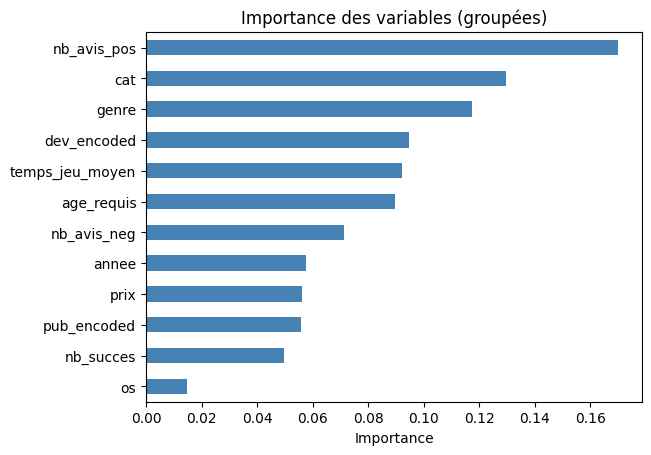

In [10]:
def plot_feature_importances(model, features, ax):
    importances = pd.Series(model.feature_importances_, index=features)

    def get_group(col):
        if col.startswith("genre_"): 
            return "genre"
        if col.startswith("cat_"):
            return "cat"
        if col.startswith("os_"):
            return "os"
        return col

    grouped = importances.groupby(get_group).sum()
    grouped.sort_values(ascending=True).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("Importance des variables (groupées)")
    ax.set_xlabel("Importance")

plot_feature_importances(model, var_caracteristiques, plt.gca())

## Fonction valeurs prédites vs valeurs réelles

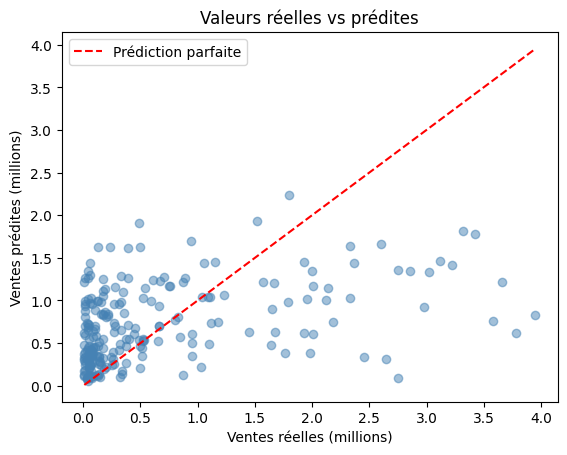

In [7]:
def plot_actual_vs_predicted(y_test, predictions, ax):
    ax.scatter(y_test, predictions, alpha=0.5, color="steelblue")
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', label="Prédiction parfaite")
    ax.set_title("Valeurs réelles vs prédites")
    ax.set_xlabel("Ventes réelles (millions)")
    ax.set_ylabel("Ventes prédites (millions)")
    ax.legend()

plot_actual_vs_predicted(y_test, predictions, plt.gca())

## Fonction plot des résidus

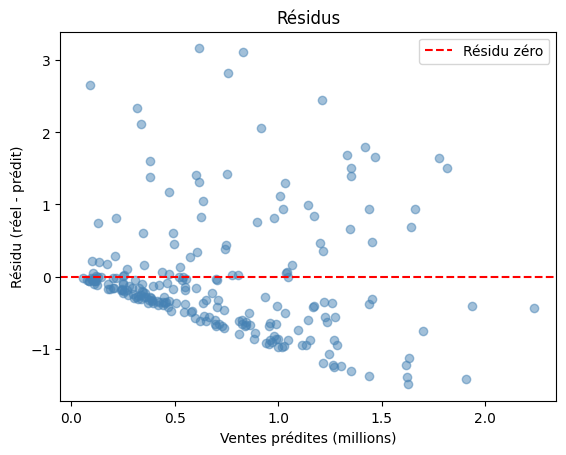

In [8]:
def plot_residuals(y_test, predictions, ax):
    residuals = y_test.values - predictions
    ax.scatter(predictions, residuals, alpha=0.5, color="steelblue")
    ax.axhline(0, color='r', linestyle='--', label="Résidu zéro")
    ax.set_title("Résidus")
    ax.set_xlabel("Ventes prédites (millions)")
    ax.set_ylabel("Résidu (réel - prédit)")
    ax.legend()
plot_residuals(y_test, predictions, plt.gca())

## Un arbre de décision

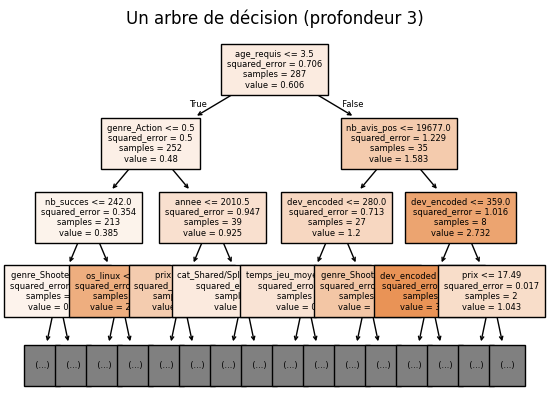

In [9]:
def plot_single_tree(model, features, ax):
    plot_tree(model.estimators_[0],
              feature_names=features,
              max_depth=3,
              filled=True,
              ax=ax,
              fontsize=6)
    ax.set_title("Un arbre de décision (profondeur 3)")
plot_single_tree(model, var_caracteristiques, plt.gca())